# EE200 Course Project - Q2

## The Midnight Episode: Catching the Arrhythmia

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

### Loading the Data

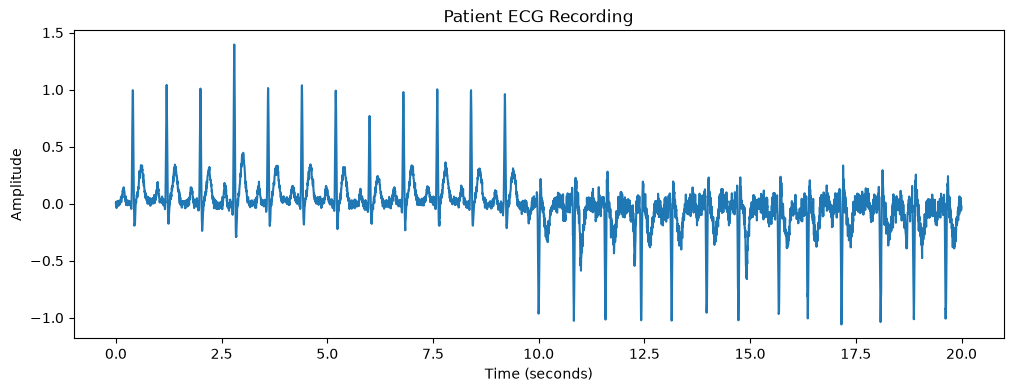

In [3]:
ecg_signal = np.load('Q2_data/patient_ecg.npy')
template = np.load('Q2_data/template.npy')

fs = 250 # Sampling frequency in Hz
N = len(ecg_signal)
time = np.arange(N) / fs

plt.figure(figsize=(12, 4))
plt.plot(time, ecg_signal)
plt.title('Patient ECG Recording')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.show()

### (a) Reading the signal
(i) How many seconds long is the clip?

(ii) In the healthy stretch, what is the patient’s heart rate in beats per minute,
and how many samples does one healthy
beat occupy?

(iii) Treating the healthy ECG as a periodic
signal, what is its fundamental frequency
f0 (in Hz)?

In [4]:
total_seconds = N / fs
beat_interval_sec = 0.8
heart_rate_bpm = 60 / beat_interval_sec
samples_per_beat = int(beat_interval_sec * fs)
fundamental_freq = 1 / beat_interval_sec

print(f"(i) Clip duration: {total_seconds} seconds")
print(f"(ii) Heart rate: {heart_rate_bpm} BPM. Samples per healthy beat: {samples_per_beat}")
print(f"(iii) Fundamental frequency (f0): {fundamental_freq} Hz")

(i) Clip duration: 20.0 seconds
(ii) Heart rate: 75.0 BPM. Samples per healthy beat: 200
(iii) Fundamental frequency (f0): 1.25 Hz


### (g) Prototyping the detector in code
Writing the `find_onset` function to calculate normalized correlation beat-by-beat and identify the onset index.

In [5]:
def find_onset(ecg_signal, template, threshold=0.5):
    L = len(template)
    N = len(ecg_signal)
    norm_t = np.linalg.norm(template)
    
    correlations = []
    indices = []
    
    # Jumping forward by the length of the template each time
    for m in range(0, N - L + 1, L):
        segment = ecg_signal[m:m+L]
        norm_x = np.linalg.norm(segment)
        
        if norm_x == 0:
            corr = 0
        else:
            corr = np.dot(template, segment) / (norm_t * norm_x)
            
        correlations.append(corr)
        indices.append(m)
        
        if corr < threshold:
            return m
            
    return -1

onset_index = find_onset(ecg_signal, template, threshold=0.5)
onset_time = onset_index / fs if onset_index != -1 else -1
print(f"Arrhythmia Onset detected at index: {onset_index} (Time: {onset_time:.2f} s)")

Arrhythmia Onset detected at index: 2400 (Time: 9.60 s)


### (h) Visualizing the Spectrogram
Computing and plotting the spectrogram using `scipy.signal` and `matplotlib.pyplot`.

*Window Length Justification*: To reveal steady horizontal harmonic bands (good frequency resolution) in the healthy region while maintaining enough time resolution to spot the onset, we need a window that covers a few beats. At $fs=250$ Hz and 0.8s per beat, 1 beat is 200 samples. A window of around 600-800 samples (3-4 beats) is ideal. We choose `nperseg=600`.

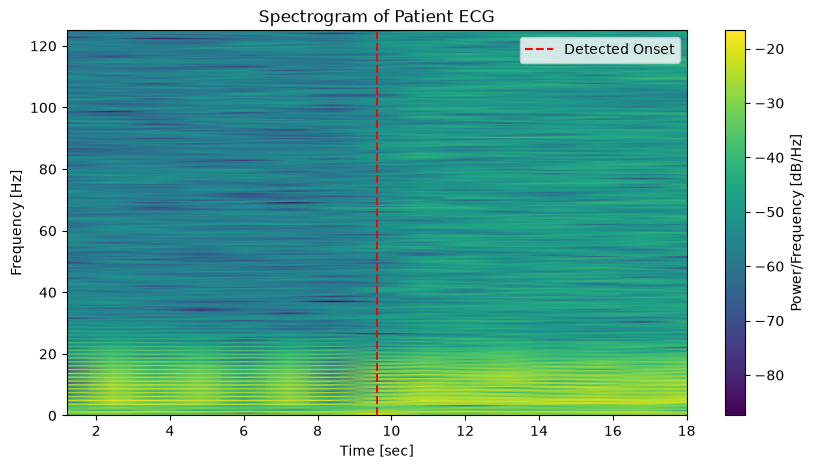

In [6]:
nperseg = 600 # Window length
f_spec, t_spec, Sxx = signal.spectrogram(ecg_signal, fs=fs, nperseg=nperseg, noverlap=nperseg//2)

plt.figure(figsize=(10, 5))
plt.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
plt.title('Spectrogram of Patient ECG')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Power/Frequency [dB/Hz]')
plt.axvline(x=onset_time, color='red', linestyle='--', label='Detected Onset')
plt.legend()
plt.show()